In [1]:
print("Notebook is working!")

Notebook is working!


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

In [3]:
import os

print(os.getcwd())

c:\Users\Srinithya J\Desktop\Primetrade_Assignment


In [4]:
import os

print(os.listdir())

['data', 'images', 'notebook', 'README.md.txt', 'report', 'venv']


In [5]:
import os

print(os.listdir("data"))

['fear_greed_index.csv', 'historical_data.csv']


In [6]:
import pandas as pd

trades = pd.read_csv("data/historical_data.csv")
sentiment = pd.read_csv("data/fear_greed_index.csv")

In [7]:
trades["Timestamp"] = pd.to_datetime(trades["Timestamp"], unit="ms")

In [8]:
trades["Timestamp"].head()

0   2024-10-27 03:33:20
1   2024-10-27 03:33:20
2   2024-10-27 03:33:20
3   2024-10-27 03:33:20
4   2024-10-27 03:33:20
Name: Timestamp, dtype: datetime64[ns]

In [9]:
sentiment["date"] = pd.to_datetime(sentiment["date"])

In [10]:
trades["Date"] = trades["Timestamp"].dt.date
sentiment["Date"] = sentiment["date"].dt.date

In [11]:
merged = pd.merge(
    trades,
    sentiment[["Date", "classification"]],
    on="Date",
    how="left"
)

In [12]:
merged["classification"].value_counts(dropna=False)

classification
Fear             133871
Greed             36289
NaN               26961
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64

In [13]:
merged.head()
merged.info()
merged.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  object        
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,211224
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,2025-01-24 18:44:50.421542912
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,2023-03-28 10:40:00
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,2025-02-19 21:20:00
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,2025-02-19 21:20:00
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,2025-02-19 21:20:00
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,2025-06-15 15:06:40
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,NaN


In [14]:
merged.isnull().sum()

Account                 0
Coin                    0
Execution Price         0
Size Tokens             0
Size USD                0
Side                    0
Timestamp IST           0
Start Position          0
Direction               0
Closed PnL              0
Transaction Hash        0
Order ID                0
Crossed                 0
Fee                     0
Trade ID                0
Timestamp               0
Date                    0
classification      26961
dtype: int64

In [15]:
merged["classification"].value_counts()

classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64

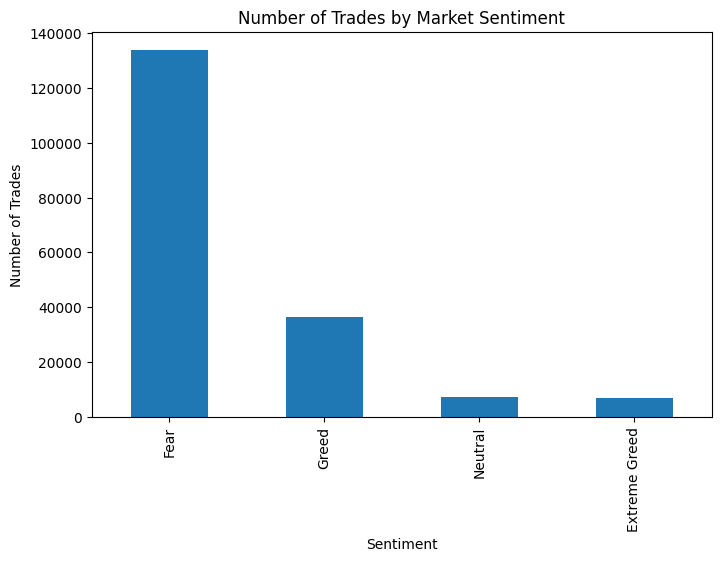

In [16]:
import matplotlib.pyplot as plt

merged["classification"].value_counts().plot(kind="bar", figsize=(8,5))
plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Trades")
plt.show()

classification
Extreme Greed    1.769655e+05
Fear             6.699925e+06
Greed            3.189617e+06
Neutral          1.587424e+05
Name: Closed PnL, dtype: float64


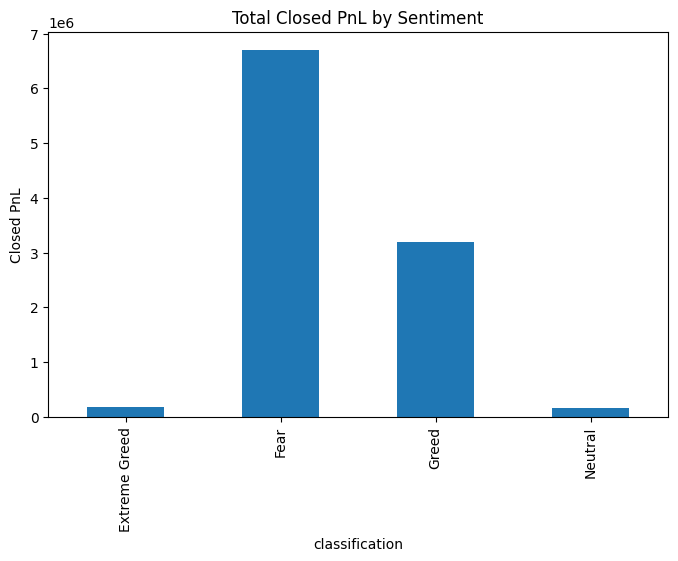

In [17]:
profit = merged.groupby("classification")["Closed PnL"].sum()
print(profit)

profit.plot(kind="bar", figsize=(8,5))
plt.title("Total Closed PnL by Sentiment")
plt.ylabel("Closed PnL")
plt.show()

classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: Closed PnL, dtype: float64


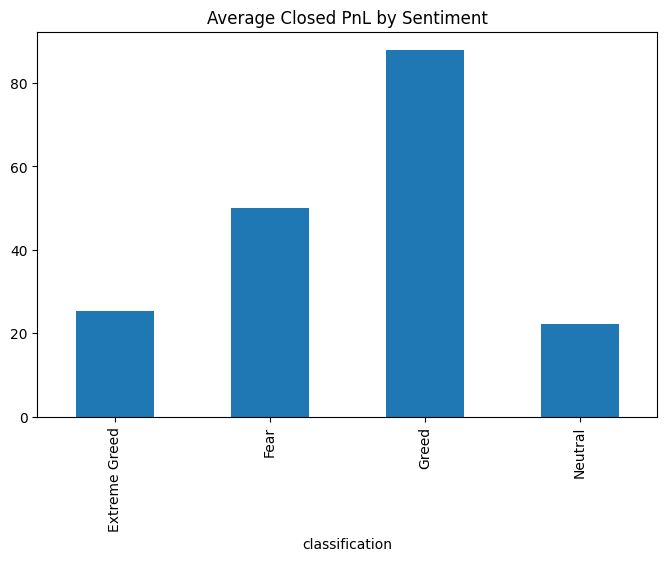

In [18]:
avg_profit = merged.groupby("classification")["Closed PnL"].mean()
print(avg_profit)

avg_profit.plot(kind="bar", figsize=(8,5))
plt.title("Average Closed PnL by Sentiment")
plt.show()

In [19]:
merged["Win"] = merged["Closed PnL"] > 0

win_rate = merged.groupby("classification")["Win"].mean() * 100
print(win_rate)

classification
Extreme Greed    49.008905
Fear             41.514592
Greed            44.647138
Neutral          31.718247
Name: Win, dtype: float64


Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64


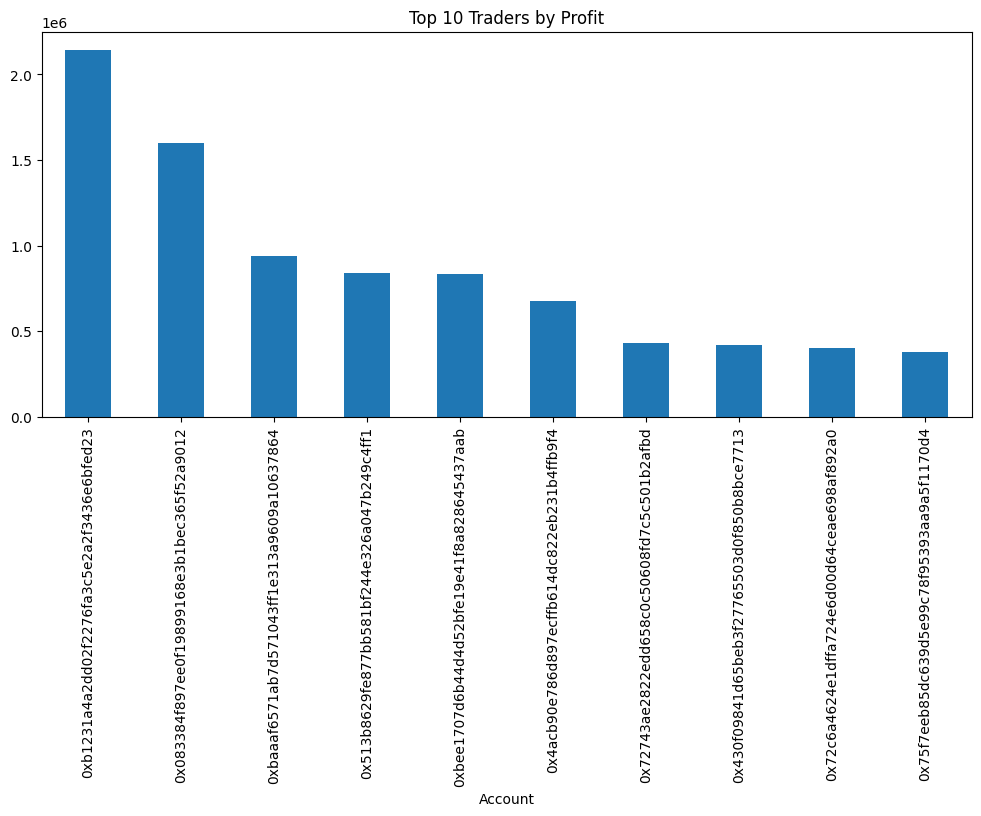

In [20]:
top_traders = merged.groupby("Account")["Closed PnL"].sum().sort_values(ascending=False).head(10)
print(top_traders)

top_traders.plot(kind="bar", figsize=(12,5))
plt.title("Top 10 Traders by Profit")
plt.show()

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64


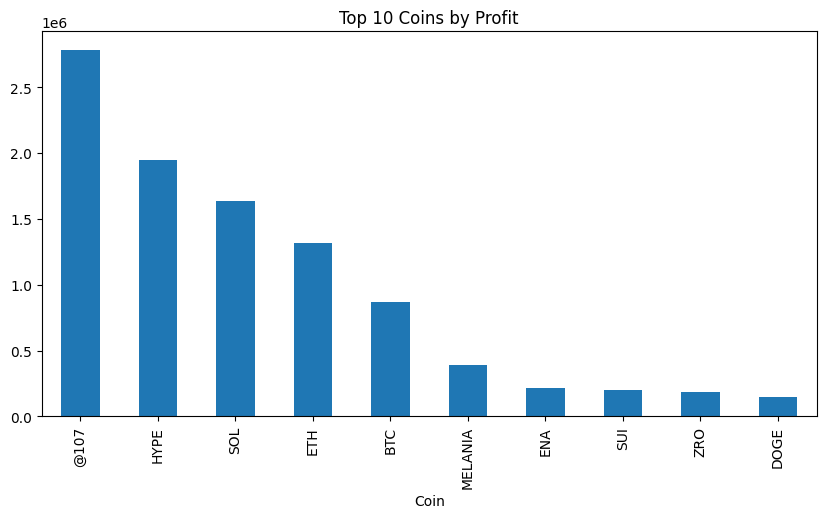

In [21]:
coin_profit = merged.groupby("Coin")["Closed PnL"].sum().sort_values(ascending=False)
print(coin_profit.head(10))

coin_profit.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Coins by Profit")
plt.show()

In [22]:
merged.groupby("classification")["Size USD"].mean()

classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64

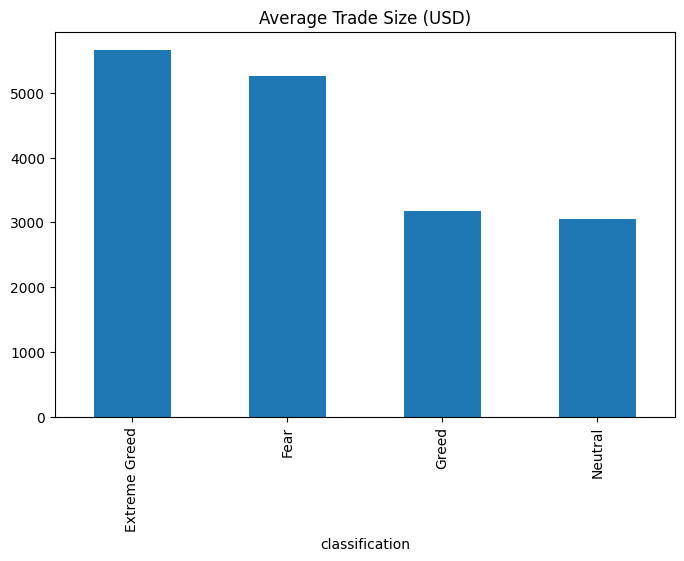

In [23]:
merged.groupby("classification")["Size USD"].mean().plot(kind="bar", figsize=(8,5))
plt.title("Average Trade Size (USD)")
plt.show()

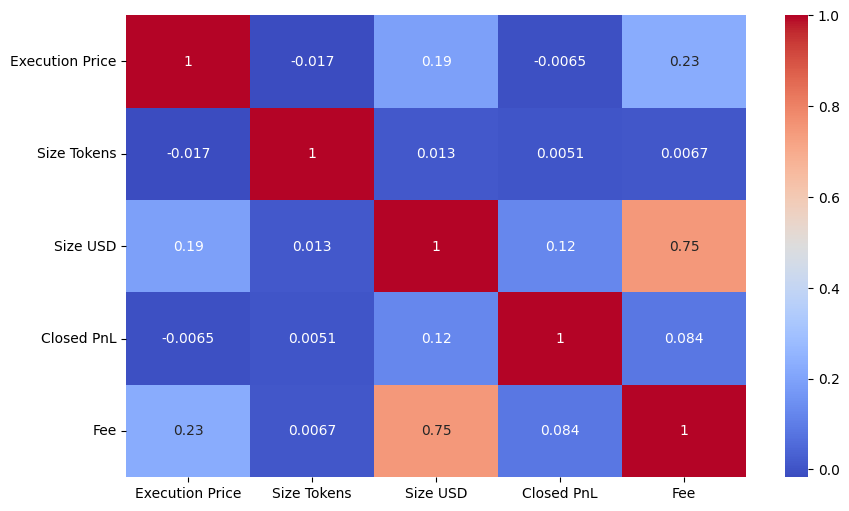

In [24]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    merged[["Execution Price","Size Tokens","Size USD","Closed PnL","Fee"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

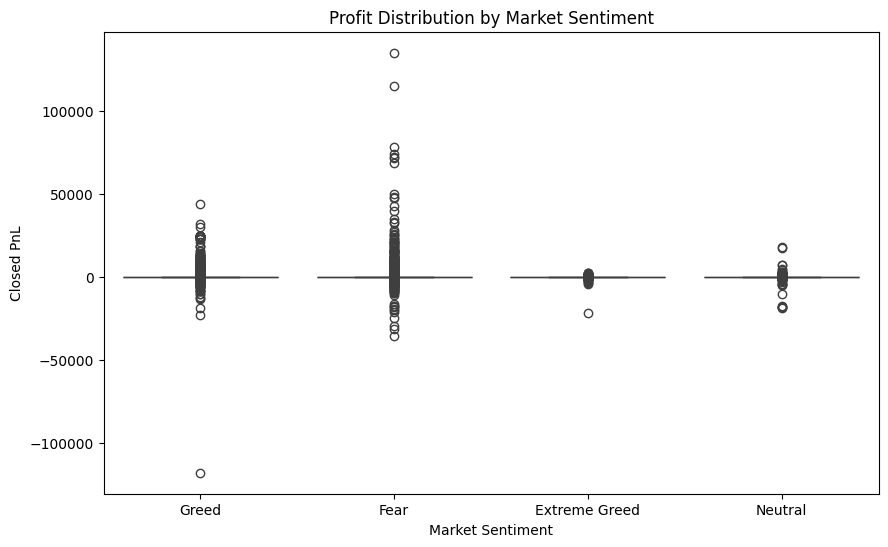

In [25]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=merged,
    x="classification",
    y="Closed PnL"
)

plt.title("Profit Distribution by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.show()

In [26]:
daily_profit = merged.groupby("Date")["Closed PnL"].sum()

daily_profit.head()

Date
2023-03-28    0.000000e+00
2023-11-14    1.555034e+02
2024-03-09    1.769655e+05
2024-07-03    1.587424e+05
2024-10-27    3.189461e+06
Name: Closed PnL, dtype: float64

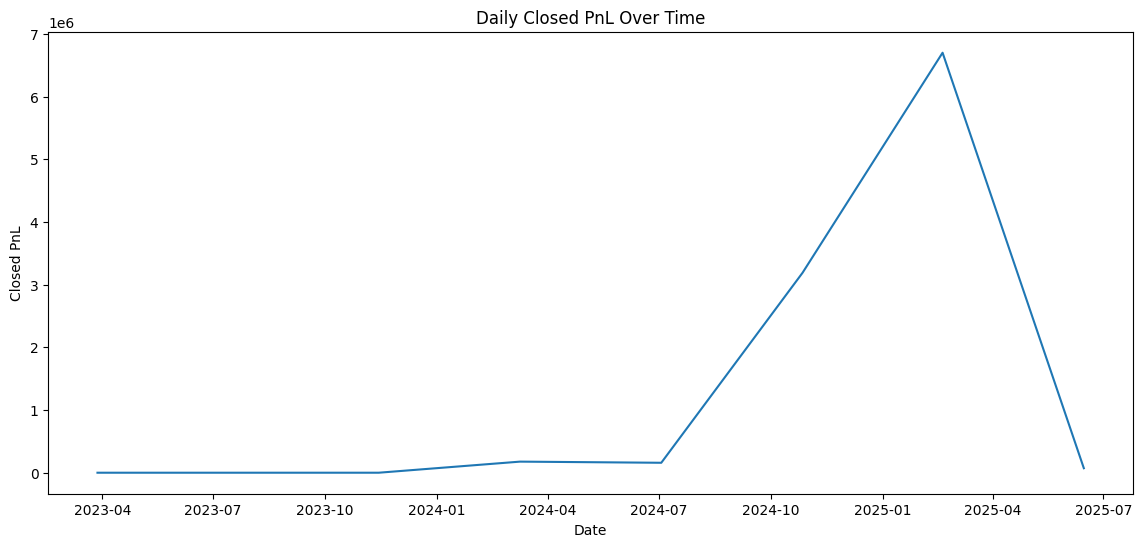

In [27]:
plt.figure(figsize=(14,6))

daily_profit.plot()

plt.title("Daily Closed PnL Over Time")
plt.xlabel("Date")
plt.ylabel("Closed PnL")

plt.show()

In [28]:
coin_count = merged["Coin"].value_counts()

coin_count.head(10)

Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: count, dtype: int64

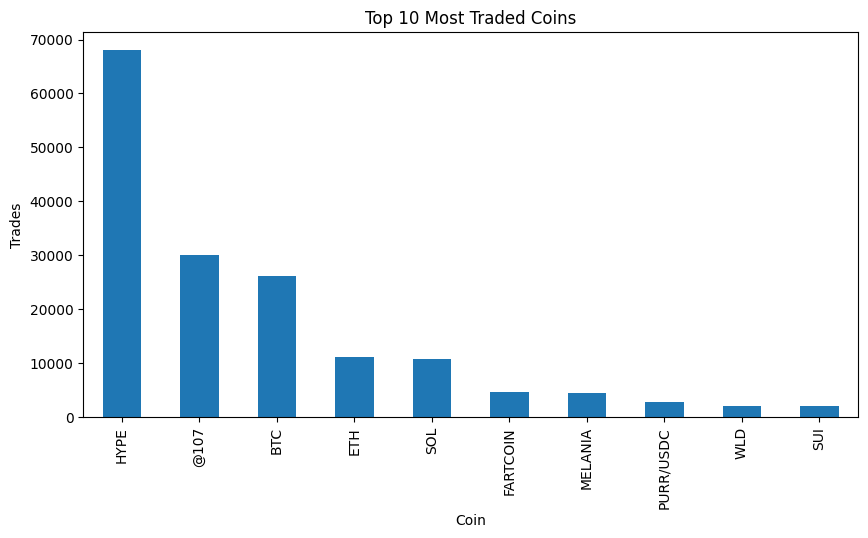

In [29]:
plt.figure(figsize=(10,5))

coin_count.head(10).plot(kind="bar")

plt.title("Top 10 Most Traded Coins")
plt.xlabel("Coin")
plt.ylabel("Trades")

plt.show()

In [30]:
side_count = merged["Side"].value_counts()

print(side_count)

Side
SELL    108528
BUY     102696
Name: count, dtype: int64


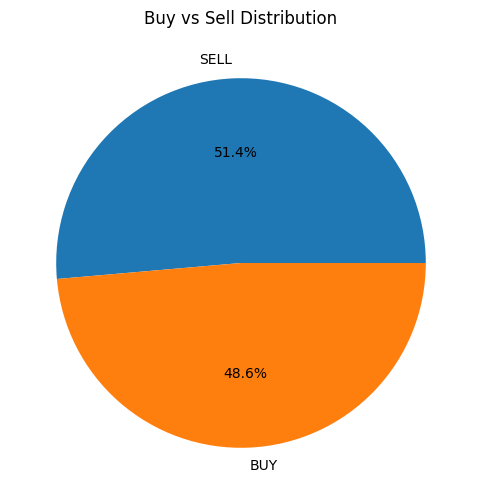

In [31]:
plt.figure(figsize=(6,6))

side_count.plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")

plt.title("Buy vs Sell Distribution")

plt.show()

In [32]:
fee = merged.groupby("classification")["Fee"].mean()

print(fee)

classification
Extreme Greed    0.978567
Fear             1.083267
Greed            0.670562
Neutral          1.224461
Name: Fee, dtype: float64


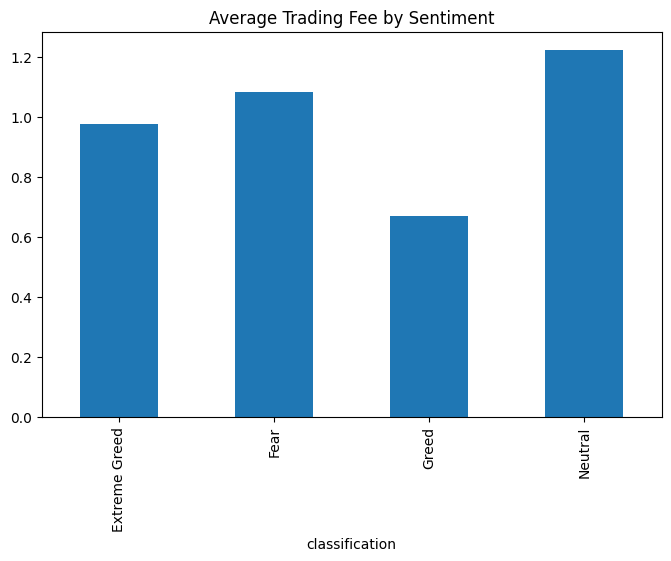

In [33]:
fee.plot(kind="bar", figsize=(8,5))

plt.title("Average Trading Fee by Sentiment")

plt.show()

In [34]:
plt.savefig("images/chart_name.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>